<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [4]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [5]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [6]:
## Write your code here
# 1. Identify and count the total number of duplicate rows
initial_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows identified: {initial_duplicates}")

# 2. Remove duplicate rows (keeping the first occurrence by default)
# Direct reassignment is the modern, warning-free standard for Copy-on-Write
df = df.drop_duplicates()

# 3. Verify the removal 
remaining_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows remaining after removal: {remaining_duplicates}")


Number of duplicate rows identified: 10Number of duplicate rows remaining after removal: 0

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [7]:
## Write your code here
# Count the total number of missing values in CodingActivities
missing_coding_acts = df['CodingActivities'].isnull().sum()

print(f"Number of missing values in 'CodingActivities': {missing_coding_acts}")


Number of missing values in 'CodingActivities': 10971

##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [8]:
## Write your code here
# 1. Impute missing values using forward-fill via safe column reassignment
df['CodingActivities'] = df['CodingActivities'].ffill()

# 2. Verify that there are no remaining missing values in this column
remaining_missing = df['CodingActivities'].isnull().sum()
print(f"Remaining missing values in 'CodingActivities': {remaining_missing}")


Remaining missing values in 'CodingActivities': 0

**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [9]:
## Write your code here
# 1. Search for column names containing "comp" or "salary" (case-insensitive)
comp_columns = [col for col in df.columns if 'comp' in col.lower() or 'salary' in col.lower()]

print("--- Detected Compensation Columns ---")
if comp_columns:
    for idx, col_name in enumerate(comp_columns, start=1):
        print(f"{idx}. Column Name: '{col_name}' | Data Type: {df[col_name].dtype}")
else:
    print("No columns containing 'comp' or 'salary' were found in the dataset.")


--- Detected Compensation Columns ---
1. Column Name: 'CompTotal' | Data Type: float64
2. Column Name: 'AIComplex' | Data Type: str
3. Column Name: 'ConvertedCompYearly' | Data Type: float64

##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [10]:
## Write your code here
# 1. Handle missing values first (Min-Max scaling fails if NaNs are present)
# Option: Impute missing rows with the median salary
comp_median = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(comp_median)

# 2. Extract the minimum and maximum values of the column
min_val = df['ConvertedCompYearly'].min()
max_val = df['ConvertedCompYearly'].max()

print(f"Original Minimum Salary: ${min_val:,.2f}")
print(f"Original Maximum Salary: ${max_val:,.2f}\n")

# 3. Apply Min-Max Scaling formula
# We save this into a new column so you don't overwrite your original dollar values
df['ConvertedCompYearly_normalized'] = (df['ConvertedCompYearly'] - min_val) / (max_val - min_val)

# 4. Verify the transformation by printing the new min, max, and first few rows
print("--- Normalized Column Verification ---")
print(f"New Minimum Value: {df['ConvertedCompYearly_normalized'].min()}")
print(f"New Maximum Value: {df['ConvertedCompYearly_normalized'].max()}")
print("\nFirst few scaled values:")
print(df[['ConvertedCompYearly', 'ConvertedCompYearly_normalized']].head())


Original Minimum Salary: $1.00
Original Maximum Salary: $16,256,603.00

--- Normalized Column Verification ---
New Minimum Value: 0.0
New Maximum Value: 1.0

First few scaled values:
   ConvertedCompYearly  ConvertedCompYearly_normalized
0              65000.0                        0.003998
1              65000.0                        0.003998
2              65000.0                        0.003998
3              65000.0                        0.003998
4              65000.0                        0.003998

##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [11]:
## Write your code here
# 1. Handle missing values first (Z-score calculation fails if NaNs are present)
# Option: Impute missing rows with the median salary
comp_median = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(comp_median)

# 2. Calculate the mean and standard deviation
mean_val = df['ConvertedCompYearly'].mean()
std_val = df['ConvertedCompYearly'].std()

print(f"Original Mean Salary:               ${mean_val:,.2f}")
print(f"Original Standard Deviation:       ${std_val:,.2f}\n")

# 3. Apply Z-score Normalization formula
# We save this into a new column so you don't lose your original dollar values
df['ConvertedCompYearly_zscore'] = (df['ConvertedCompYearly'] - mean_val) / std_val

# 4. Verify the transformation (Mean should be ~0 and Std Dev should be exactly 1)
print("--- Z-score Column Verification ---")
print(f"New Mean Value (should be ~0):     {df['ConvertedCompYearly_zscore'].mean():.4f}")
print(f"New Standard Deviation (should be 1): {df['ConvertedCompYearly_zscore'].std():.4f}")
print("\nFirst few Z-score standardized values:")
print(df[['ConvertedCompYearly', 'ConvertedCompYearly_zscore']].head())


Original Mean Salary:               $72,576.36
Original Standard Deviation:       $112,220.68

--- Z-score Column Verification ---
New Mean Value (should be ~0):     -0.0000
New Standard Deviation (should be 1): 1.0000

First few Z-score standardized values:
   ConvertedCompYearly  ConvertedCompYearly_zscore
0              65000.0                   -0.067513
1              65000.0                   -0.067513
2              65000.0                   -0.067513
3              65000.0                   -0.067513
4              65000.0                   -0.067513

### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


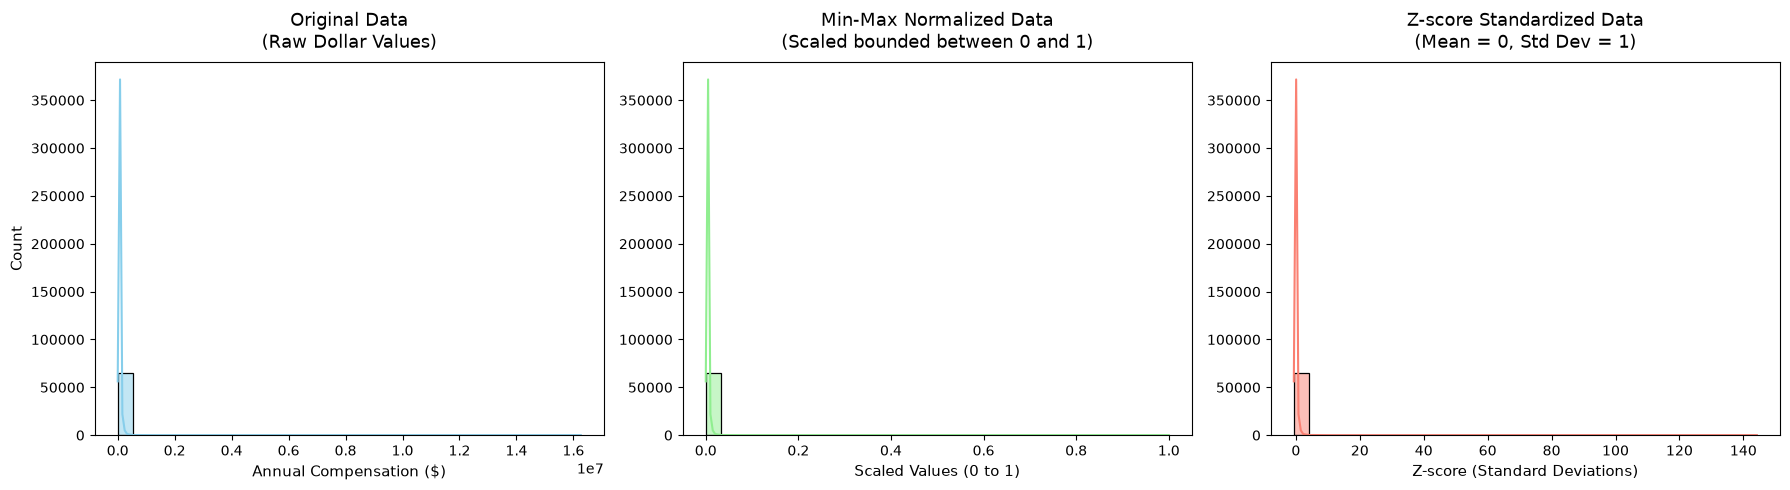

In [12]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 1-row, 3-column plot layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot Original Compensation Data
sns.histplot(data=df, x='ConvertedCompYearly', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Data\n(Raw Dollar Values)', fontsize=13, pad=10)
axes[0].set_xlabel('Annual Compensation ($)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

# 2. Plot Min-Max Normalized Data
sns.histplot(data=df, x='ConvertedCompYearly_normalized', bins=30, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Min-Max Normalized Data\n(Scaled bounded between 0 and 1)', fontsize=13, pad=10)
axes[1].set_xlabel('Scaled Values (0 to 1)', fontsize=11)
axes[1].set_ylabel('') # Clear y-label for middle plot to keep it clean

# 3. Plot Z-score Standardized Data
sns.histplot(data=df, x='ConvertedCompYearly_zscore', bins=30, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Z-score Standardized Data\n(Mean = 0, Std Dev = 1)', fontsize=13, pad=10)
axes[2].set_xlabel('Z-score (Standard Deviations)', fontsize=11)
axes[2].set_ylabel('') # Clear y-label for right plot to keep it clean

# Adjust layout padding so titles and axes labels do not overlap
plt.tight_layout()

# Display the charts
plt.show()


### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
